# 13 — Quadratic-impact controlled SDE

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from optimizr import _core as opt
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['figure.dpi'] = 110


## Riccati fixed-point check

$h'(t) = h(t)^2/γ - φ$ with $h(T) = A$.  When $γ = φ = A = 1$ the right-hand side is $h^2 - 1 = 0$ at $h = 1$, so `h ≡ 1`.

In [2]:
res = opt.quadratic_impact_control_py(
    gamma=1.0, phi=1.0, a_terminal=1.0,
    t_horizon=0.5, n_steps=500,
)
tg = np.array(res['time_grid'])
h  = np.array(res['h']); k = np.array(res['feedback_gain'])
print('h drift from 1:', float(np.max(np.abs(h - 1.0))))


h drift from 1: 0.0


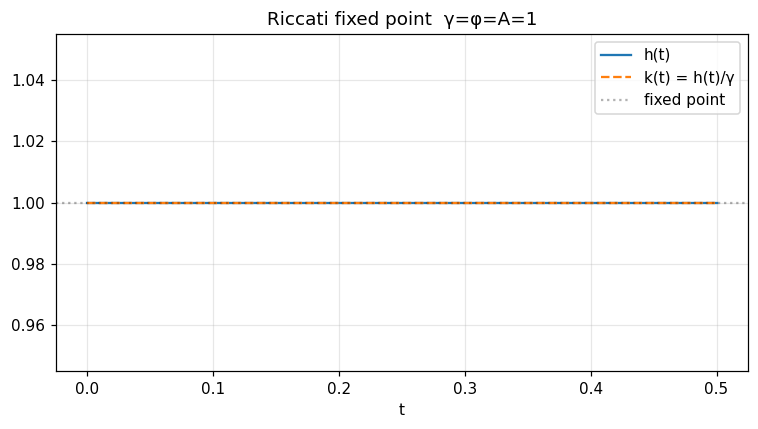

In [3]:
fig, ax = plt.subplots()
ax.plot(tg, h, label='h(t)')
ax.plot(tg, k, '--', label='k(t) = h(t)/γ')
ax.axhline(1.0, color='k', alpha=0.3, ls=':', label='fixed point')
ax.set_xlabel('t'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Riccati fixed point  γ=φ=A=1')
fig.tight_layout(); plt.show()


## Sensitivity to the terminal weight

Vary $A$, fix $γ = 1$, $φ = 0.25$, $T = 1$.

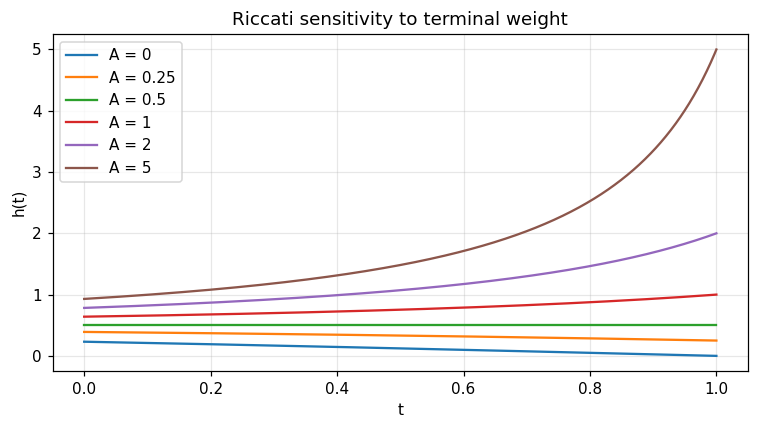

In [4]:
fig, ax = plt.subplots()
for A in [0.0, 0.25, 0.5, 1.0, 2.0, 5.0]:
    r = opt.quadratic_impact_control_py(1.0, 0.25, A, 1.0, 1000)
    ax.plot(r['time_grid'], r['h'], label=f'A = {A:g}')
ax.set_xlabel('t'); ax.set_ylabel('h(t)'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Riccati sensitivity to terminal weight')
fig.tight_layout(); plt.show()


**Verified:** `h ≡ 1` with `max|h - 1| < 1e-9` at the fixed point.